In [13]:
import json
import pandas as pd
from io import StringIO
import matplotlib.pyplot as plt

plt.rcParams.update(
    {
        "font.family": "Times New Roman",
        # "font.serif": "CMU Serif",
        # "font.serif": "Times New Roman",
        "text.usetex": True,
        "text.latex.preamble": r"\usepackage{amsmath}",
        "font.size": 18,
        "font.weight": "normal",
        "figure.titlesize": "medium",
        "xtick.color": "black",
        "ytick.color": "black",
        "axes.labelcolor": "black",
        "text.color": "black",
        "savefig.dpi": 300,
        "figure.dpi": 150,
        "savefig.bbox": "tight",
    }
)



# Specify the path to your JSON file
json_file_path = 'C:/Users/nicho/OneDrive/Desktop/Vaccine_Tender/horizon excursion/15 years - Unvax penalty sensitivity/Beta_results.json'  # Replace with the actual path

# Load JSON data from the file
with open(json_file_path, 'r') as file:
    data_list = [json.loads(line) for line in file]

# Create an empty list to store DataFrames
dfs = []

# Iterate through the list of dictionaries and create DataFrames
for entry in data_list:
    beta_value = entry["beta_value"]
    obj_value = entry["obj_value"]
    df_entry = pd.DataFrame({'beta': [beta_value], 'OBJ': [obj_value]})
    dfs.append(df_entry)

# Concatenate the list of DataFrames into a single DataFrame
df = pd.concat(dfs, ignore_index=True)

df = df.sort_values(by='beta')
# df = df[df.beta < 4]
# df

In [2]:
df

,beta,OBJ
15,0.40,2.582899e+10
14,0.50,2.689192e+10
13,0.60,2.777781e+10
19,0.65,2.807295e+10
12,0.70,2.828652e+10
11,0.80,2.866770e+10
10,0.90,2.893803e+10
9,1.00,2.918634e+10
18,1.05,2.930110e+10
17,1.10,2.940856e+10


In [3]:
df.drop(18, inplace=True)
df.drop(19, inplace=True)
df.drop(20, inplace=True)

In [4]:
df

,beta,OBJ
15,0.4,2.582899e+10
14,0.5,2.689192e+10
13,0.6,2.777781e+10
12,0.7,2.828652e+10
11,0.8,2.866770e+10
10,0.9,2.893803e+10
9,1.0,2.918634e+10
17,1.1,2.940856e+10
16,1.2,2.959374e+10
21,1.4,2.988851e+10


In [5]:

# Specify the path to your JSON file
json_file_path = 'C:/Users/nicho/OneDrive/Desktop/Vaccine_Tender/horizon excursion/JSON/unvaccinated_children_totals.json'  # Replace with the actual path

# Load JSON data from the file
with open(json_file_path, 'r') as file:
    data_list2 = [json.loads(line) for line in file]

# Create an empty list to store DataFrames
unvax_dfs = []

# Iterate through the list of dictionaries and create DataFrames
for entry in data_list2:
    beta_value = entry["beta_value"]
    unvax_sum = entry["sum"]
    df2_entry = pd.DataFrame({'beta': [beta_value], 'SUM': [unvax_sum]})
    unvax_dfs.append(df2_entry)

# Concatenate the list of DataFrames into a single DataFrame
df_unvax = pd.concat(unvax_dfs, ignore_index=True)

# Sort the DataFrame by the 'beta' column
df_unvax = df_unvax.sort_values(by='beta')


In [6]:
df_unvax.drop(23, inplace=True)

In [7]:
merged_df = pd.merge(df, df_unvax, left_on='beta', right_on='beta')

In [8]:
merged_df['Adjusted_Objective'] = merged_df['OBJ'] - (merged_df['SUM'] * merged_df['beta'])

In [9]:
merged_df = merged_df[merged_df.beta <6]

In [10]:
merged_df

,beta,OBJ,SUM,Adjusted_Objective
0,0.4,2.582899e+10,1.157345e+10,2.119961e+10
1,0.5,2.689192e+10,9.246490e+09,2.226868e+10
2,0.6,2.777781e+10,8.281117e+09,2.280914e+10
3,0.7,2.828652e+10,4.174000e+09,2.536472e+10
4,0.8,2.866770e+10,3.456405e+09,2.590258e+10
5,0.9,2.893803e+10,2.631994e+09,2.656924e+10
6,1.0,2.918634e+10,2.531864e+09,2.665448e+10
7,1.1,2.940856e+10,2.171532e+09,2.701988e+10
8,1.2,2.959374e+10,1.696896e+09,2.755746e+10
9,1.4,2.988851e+10,1.509750e+09,2.777486e+10


In [11]:
merged_df.drop(9, inplace=True)

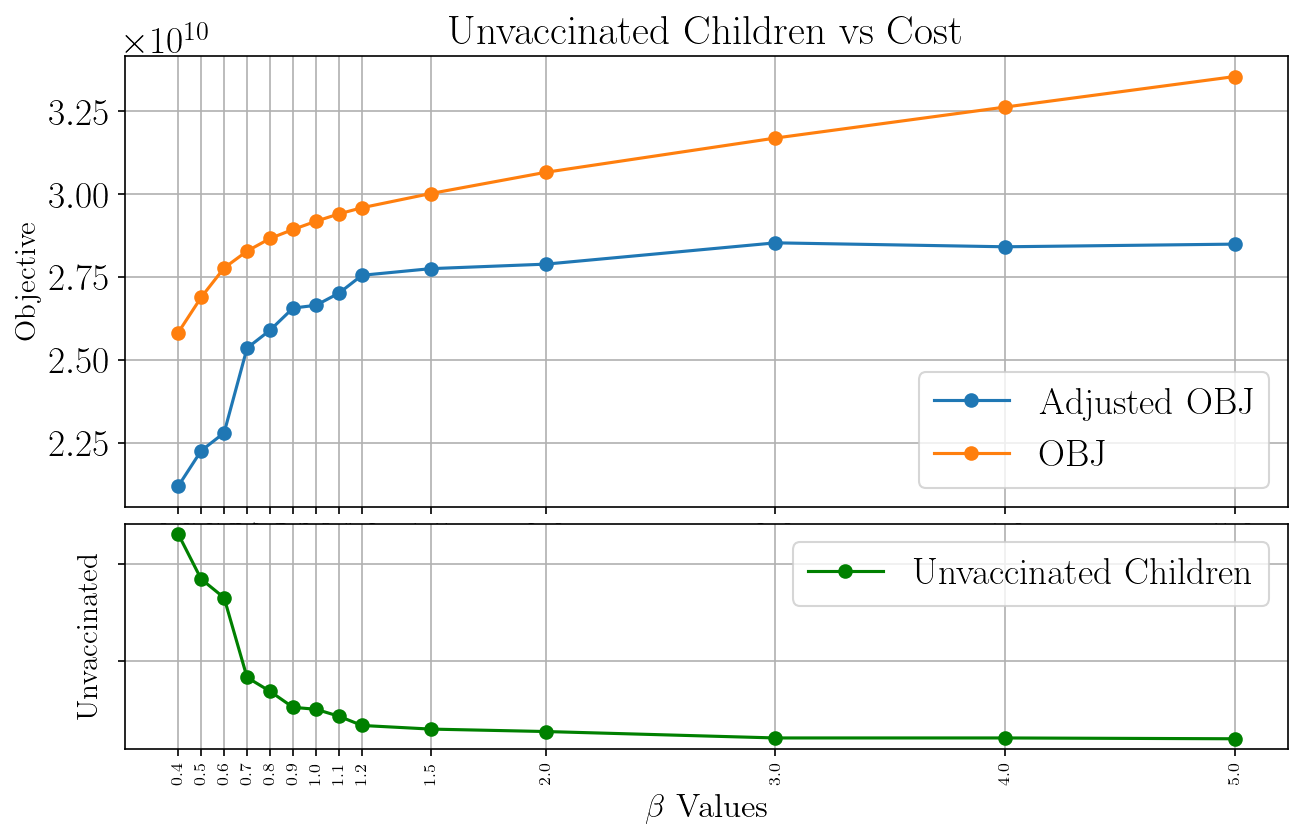

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.ticker import MaxNLocator

# Assuming merged_df is your DataFrame with columns 'beta', 'Adjusted_Objective', 'OBJ', and 'SUM'
# Adjust the column names based on your actual DataFrame

# Create a figure and a grid with 2 rows and 1 column
fig = plt.figure(figsize=(10, 6))
gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1], hspace=0.05)  # Reduce vertical space between subplots

# Upper subplot for values above the break
ax0 = plt.subplot(gs[0])
ax0.plot(merged_df['beta'], merged_df['Adjusted_Objective'], marker='o', linestyle='-', label='Adjusted OBJ')
ax0.plot(merged_df['beta'], merged_df['OBJ'], marker='o', linestyle='-', label='OBJ')
ax0.legend()
ax0.set_xticks([])
ax0.set_ylabel('Objective', fontsize=14)
ax0.set_title('Unvaccinated Children vs Cost', fontsize=20, fontname="Times New Roman")
ax0.grid(True)

# Lower subplot for values below the break
ax1 = plt.subplot(gs[1], sharex=ax0)
ax1.plot(merged_df['beta'], merged_df['SUM'], marker='o', linestyle='-', color='green', label='Unvaccinated Children')
ax1.set_xlabel(r'$\beta$ Values', fontsize=16)
ax1.set_ylabel('Unvaccinated', fontsize=14)
ax1.legend()

# Set x ticks for each value of 'beta' with smaller font size
ax1.set_xticks(merged_df['beta'])
ax1.tick_params(axis='x', rotation=90, labelsize=8)
# ax0.xaxis.set_major_locator(MaxNLocator(integer=True))

# Remove the scale label on the lower plot
ax1.yaxis.set_major_formatter(plt.NullFormatter())

# Show the plot
plt.grid(True)
plt.savefig('Unvax_children_beta_curve.png', bbox_inches='tight', pad_inches=0.1, dpi=600)


# plt.tight_layout()
plt.show()


In [ ]:
merged_df